In [39]:

import pandas as pd
import numpy as np
import os

In [2]:


if os.path.exists("../data/processed/X_raw.npy"):
    print("Ucitavam vec obradjene podatke...")
    X = np.load("../data/processed/X_raw.npy")
else:
    print("Učitavam raw podatke...")
    data = pd.read_csv("../data/raw/GSE115469_Data.csv", index_col=0)
    X = data.to_numpy(dtype=np.float32)
    X = X.T
    del data

Ucitavam vec obradjene podatke...


In [3]:

print(X.shape)

(8444, 20007)


In [4]:
np.save("../data/processed/X_raw.npy", X)

In [5]:
X = np.load("../data/processed/X_raw.npy")

In [6]:
X[:5]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.31475955, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [7]:
variances = np.var(X, axis=0)
k = 3000
top_genes = np.argsort(variances)[-k:]

X = X[:, top_genes]

print(X.shape)


(8444, 3000)


In [8]:
from sklearn.preprocessing import StandardScaler   
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)
del X

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled).astype(np.float32)

print(X_pca.shape)

(8444, 50)


In [10]:
pca.explained_variance_ratio_.sum()

0.25720343

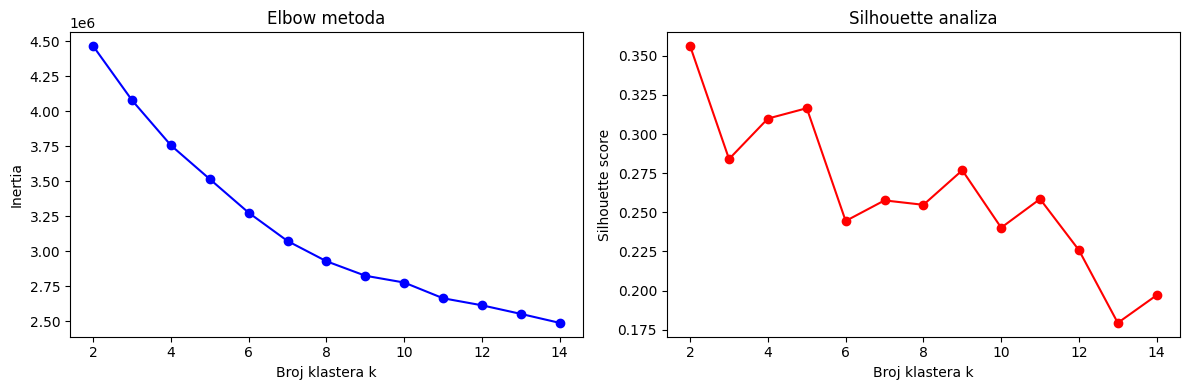

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt

inertias = []
silhouettes = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels, sample_size=2000))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel("Broj klastera k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow metoda")

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel("Broj klastera k")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette analiza")

plt.tight_layout()
plt.show()

In [45]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

np.save("../data/processed/cluster_labels.npy", cluster_labels)

score = silhouette_score(X_pca, cluster_labels, sample_size=2000)
print(f"K-Means silhouette score: {score:.4f}")
print(f"Raspodela klastera:\n {pd.Series(cluster_labels).value_counts().sort_index()}")

K-Means silhouette score: 0.3211
Raspodela klastera:
 0    3480
1    1133
2     585
3    1101
4    2145
Name: count, dtype: int64


2026-03-01 17:48:43.392233: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-01 17:48:43.414317: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-01 17:48:43.420828: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-01 17:48:43.437649: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 17:48:44.867404: W tensorflow/compiler/tf2

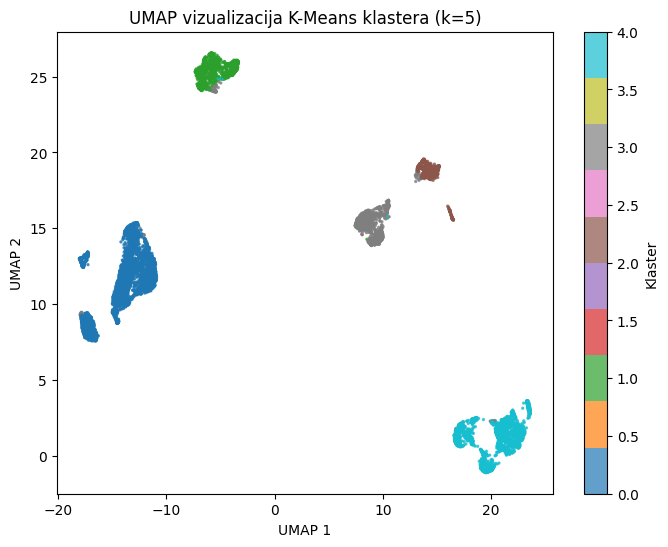

In [13]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=cluster_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija K-Means klastera (k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/X_umap.npy", X_umap)

In [14]:
X_pca.shape

(8444, 50)

In [15]:
from sklearn.cluster import AgglomerativeClustering

linkages = ['ward', 'complete', 'average']

for linkage in ['ward', 'complete', 'average']:
    agg = AgglomerativeClustering(n_clusters=5, linkage=linkage)
    labels = agg.fit_predict(X_pca)
    distribution = pd.Series(labels).value_counts().sort_index().tolist()
    print(f"linkage={linkage}: raspodela={distribution}")
    
    if min(distribution) > 5:
        score = silhouette_score(X_pca, labels, sample_size=2000)
        print(f"linkage={linkage}: silhouette={score:.4f}")
    else:
        print(f"linkage={linkage}: chaining effect, silhouette nije relevantan")

linkage=ward: raspodela=[3509, 604, 1094, 1087, 2150]
linkage=ward: silhouette=0.3052
linkage=complete: raspodela=[8440, 1, 1, 1, 1]
linkage=complete: chaining effect, silhouette nije relevantan
linkage=average: raspodela=[8440, 1, 1, 1, 1]
linkage=average: chaining effect, silhouette nije relevantan


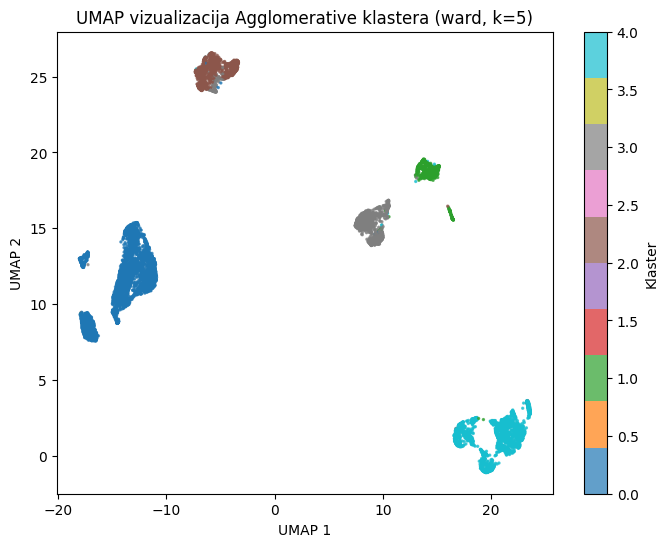

In [17]:
agg_final = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg_final.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=agg_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija Agglomerative klastera (ward, k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/agg_labels.npy", agg_labels)

In [18]:
X_raw = np.load("../data/processed/X_raw.npy")
print(X_raw.shape)

(8444, 20007)


In [19]:
def prepare_and_cluster(X, n_gens, use_pca=True, k=5):
    
    variances = np.var(X, axis=0)
    top_genes = np.argsort(variances)[-n_gens:]
    X_sel = X[:, top_genes]
    
    X_scaled = StandardScaler().fit_transform(X_sel).astype(np.float32)
    
    if use_pca:
        X_final = PCA(n_components=50, random_state=42).fit_transform(X_scaled).astype(np.float32)
        name = f"Top{n_gens}_PCA"
    else:
        X_final = X_scaled
        name = f"Top{n_gens}_bezPCA"
    
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_final)
    score = silhouette_score(X_final, labels, sample_size=2000)
    
    print(f"{name}: silhouette={score:.4f}")
    return name, score, labels

In [20]:
results = {}

for n_genes in [500, 1000, 3000]:
    name, score, labels = prepare_and_cluster(X_raw, n_genes, use_pca=True)
    results[name] = score

for n_genes in [500, 3000]:
    name, score, labels = prepare_and_cluster(X_raw, n_genes, use_pca=False)
    results[name] = score

print("\n=== COMPARISON ===")
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")

Top500_PCA: silhouette=0.1883
Top1000_PCA: silhouette=0.1843
Top3000_PCA: silhouette=0.3097
Top500_bezPCA: silhouette=0.1132
Top3000_bezPCA: silhouette=-0.0005

=== COMPARISON ===
Top3000_PCA: 0.3097
Top500_PCA: 0.1883
Top1000_PCA: 0.1843
Top500_bezPCA: 0.1132
Top3000_bezPCA: -0.0005


In [21]:
from sklearn.cluster import BisectingKMeans

configs = [
    ("Top500_PCA", 500, True),
    ("Top3000_PCA", 3000, True),
    ("Top3000_noPCA", 3000, False),
]

bisect_results = {}

for name, n_genes, use_pca in configs:
    variances = np.var(X_raw, axis=0)
    top_genes = np.argsort(variances)[-n_genes:]
    X_sel = X_raw[:, top_genes]
    
    X_scaled = StandardScaler().fit_transform(X_sel).astype(np.float32)
    
    if use_pca:
        X_final = PCA(n_components=50, random_state=42).fit_transform(X_scaled).astype(np.float32)
    else:
        X_final = X_scaled
    
    model = BisectingKMeans(n_clusters=5, random_state=42)
    labels = model.fit_predict(X_final)
    score = silhouette_score(X_final, labels, sample_size=2000)
    
    bisect_results[name] = score
    print(f"{name}: silhouette={score:.4f}")

print("\n=== BISECTING KMEANS COMPARISON ===")
for name, score in sorted(bisect_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")

Top500_PCA: silhouette=0.1702
Top3000_PCA: silhouette=0.2805
Top3000_noPCA: silhouette=0.0308

=== BISECTING KMEANS COMPARISON ===
Top3000_PCA: 0.2805
Top500_PCA: 0.1702
Top3000_noPCA: 0.0308


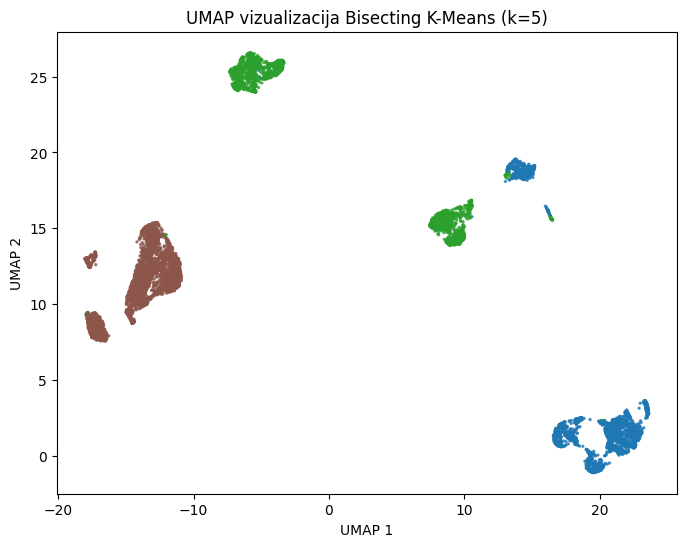

In [47]:
bisect_final = BisectingKMeans(n_clusters=5, random_state=42)
bisect_labels = bisect_final.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=bisect_labels, cmap='tab10', s=2, alpha=0.7)

plt.title('UMAP vizualizacija Bisecting K-Means (k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/bisect_labels.npy", bisect_labels)

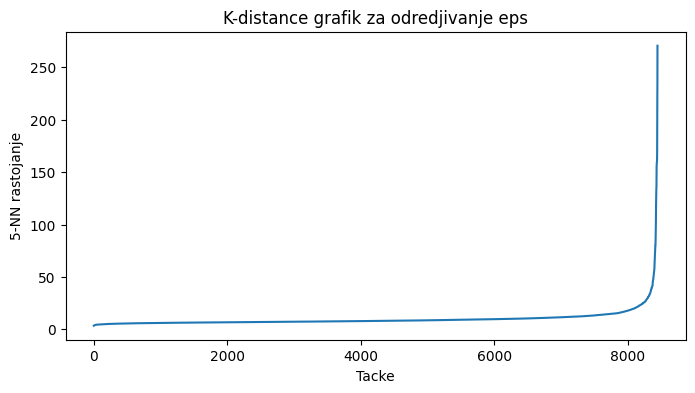

In [23]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.xlabel("Tacke")
plt.ylabel("5-NN rastojanje")
plt.title("K-distance grafik za odredjivanje eps")
plt.show()

In [24]:
for eps in [3, 5, 8, 10, 15]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_pca)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    print(f"eps={eps}: klastera={n_clusters}, noise={n_noise}, noise%={n_noise/len(labels)*100:.1f}%")

eps=3: klastera=0, noise=8444, noise%=100.0%
eps=5: klastera=14, noise=8115, noise%=96.1%
eps=8: klastera=5, noise=3454, noise%=40.9%
eps=10: klastera=3, noise=1754, noise%=20.8%
eps=15: klastera=3, noise=541, noise%=6.4%


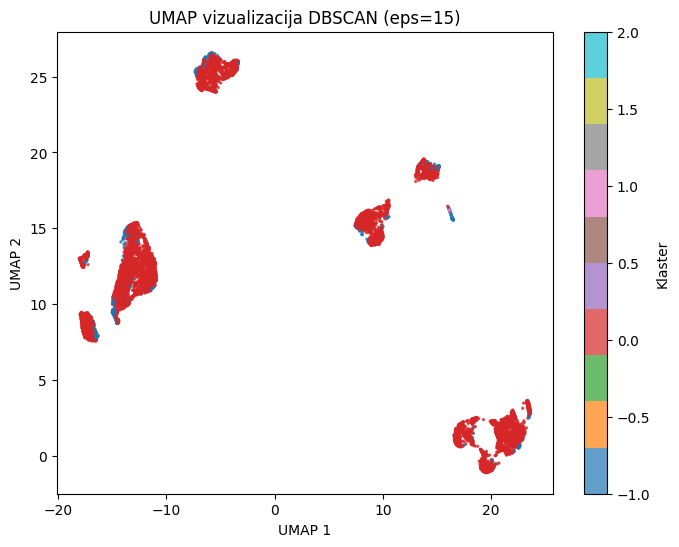

In [25]:
db_final = DBSCAN(eps=15, min_samples=5)
db_labels = db_final.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=db_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija DBSCAN (eps=15)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/db_labels.npy", db_labels)

In [26]:
mask = db_labels != -1
score = silhouette_score(X_pca[mask], db_labels[mask], sample_size=2000)
print(f"DBSCAN silhouette (bez noise): {score:.4f}")
print(f"Noise tačke: {np.sum(~mask)} ({np.sum(~mask)/len(db_labels)*100:.1f}%)")

DBSCAN silhouette (bez noise): 0.3251
Noise tačke: 541 (6.4%)


In [27]:
from sklearn_extra.cluster import KMedoids

configs = [
    ("Top500_PCA", 500, True),
    ("Top3000_PCA", 3000, True),
    ("Top3000_noPCA", 3000, False),
]

kmed_results = {}

for name, n_genes, use_pca in configs:
    variances = np.var(X_raw, axis=0)
    top_genes = np.argsort(variances)[-n_genes:]
    X_sel = X_raw[:, top_genes]
    
    X_scaled = StandardScaler().fit_transform(X_sel).astype(np.float32)
    
    if use_pca:
        X_final = PCA(n_components=50, random_state=42).fit_transform(X_scaled).astype(np.float32)
    else:
        X_final = X_scaled
    
    model = KMedoids(n_clusters=5, random_state=42)
    labels = model.fit_predict(X_final)
    score = silhouette_score(X_final, labels, sample_size=2000)
    
    kmed_results[name] = score
    print(f"{name}: silhouette={score:.4f}")

print("\n=== KMEDOIDS COMPARISON ===")
for name, score in sorted(kmed_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")

Top500_PCA: silhouette=0.2156
Top3000_PCA: silhouette=0.1622
Top3000_noPCA: silhouette=-0.0289

=== KMEDOIDS COMPARISON ===
Top500_PCA: 0.2156
Top3000_PCA: 0.1622
Top3000_noPCA: -0.0289


/home/vuk/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


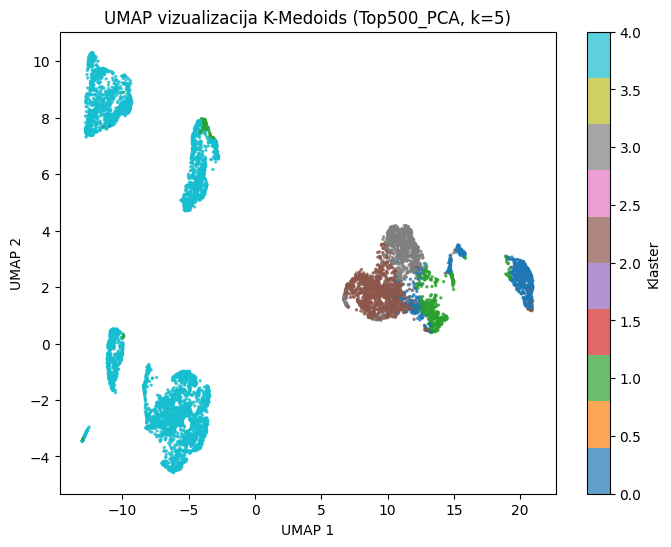

In [28]:
variances = np.var(X_raw, axis=0)
top_genes = np.argsort(variances)[-500:]
X_sel = X_raw[:, top_genes]
X_scaled_kmed = StandardScaler().fit_transform(X_sel).astype(np.float32)
X_pca_kmed = PCA(n_components=50, random_state=42).fit_transform(X_scaled_kmed).astype(np.float32)

kmed_final = KMedoids(n_clusters=5, random_state=42)
kmed_labels = kmed_final.fit_predict(X_pca_kmed)

X_umap_500 = umap.UMAP(n_components=2, random_state=42).fit_transform(X_pca_kmed)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap_500[:, 0], X_umap_500[:, 1],
                      c=kmed_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija K-Medoids (Top500_PCA, k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

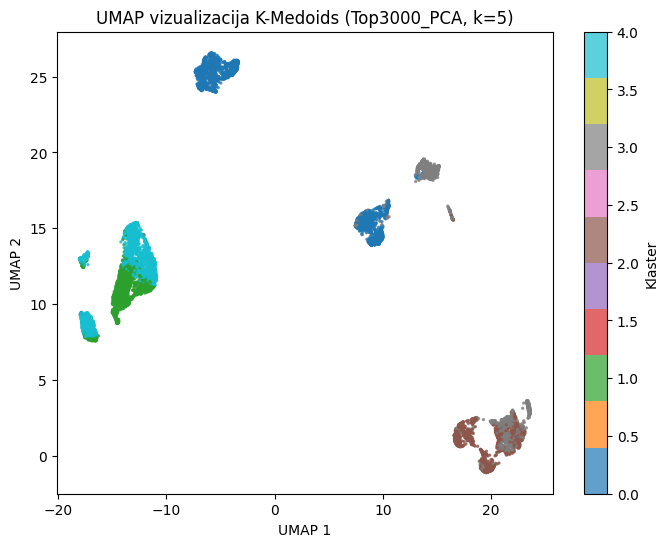

In [29]:
kmed_final = KMedoids(n_clusters=5, random_state=42)
kmed_labels = kmed_final.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=kmed_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija K-Medoids (Top3000_PCA, k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/kmed_labels.npy", kmed_labels)

In [30]:
X_binary = (X_scaled > 0).astype(bool)
print(f"Prosečan broj eksprimiranih gena po ćeliji: {X_binary.sum(axis=1).mean():.0f} od {X_binary.shape[1]}")

Prosečan broj eksprimiranih gena po ćeliji: 727 od 3000


In [31]:
for i in range(5):
    n_cells = np.sum(cluster_labels == i)
    print(f"Klaster {i}: {n_cells} celija")

Klaster 0: 3480 celija
Klaster 1: 1133 celija
Klaster 2: 585 celija
Klaster 3: 1101 celija
Klaster 4: 2145 celija


In [32]:
gene_names_all = np.load("../data/processed/gene_names.npy", allow_pickle=True)

variances = np.var(X_raw, axis=0)
top_genes = np.argsort(variances)[-3000:]
gene_names = gene_names_all[top_genes]

print(gene_names.shape) 

(3000,)


In [33]:
N_GENES_ASSOC = 12
variances = np.var(X_raw, axis=0)
top_genes_assoc = np.argsort(variances)[-N_GENES_ASSOC:]
X_assoc = X_raw[:, top_genes_assoc]
gene_names_assoc = gene_names_all[top_genes_assoc]

X_binary = (X_assoc > 0).astype(bool)
print(X_binary.shape) 

(8444, 12)


In [49]:
from mlxtend.frequent_patterns import apriori, association_rules
import time

print("=" * 60)
print("APRIORI ALGORITAM")
print("=" * 60)

apriori_results = {}

for cluster_id in range(5):
    print(f"\n=== KLASTER {cluster_id} ===")
    
    mask = cluster_labels == cluster_id
    X_cluster = X_binary[mask]
    df_cluster = pd.DataFrame(X_cluster, columns=gene_names_assoc)
    
    t0 = time.time()
    frequent_items = apriori(df_cluster, min_support=0.7, use_colnames=True, low_memory=True)
    t1 = time.time()
    
    if len(frequent_items) == 0:
        print("Nema cestih skupova sa ovim pragom")
        continue
    
    rules = association_rules(frequent_items, metric="confidence", min_threshold=0.8)
    rules = rules.sort_values("lift", ascending=False)
    
    apriori_results[cluster_id] = {
        "frequent_items": frequent_items,
        "rules": rules,
        "time_sec": round(t1 - t0, 3)
    }
    
    print(f"Cestih skupova : {len(frequent_items)}")
    print(f"Pravila        : {len(rules)}")
    print(f"Vreme (Apriori): {t1 - t0:.3f}s")
    print(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(5).to_string())

print("\n" + "=" * 60)
print("Sumarni pregled po klasterima:")
print(f"{'Klaster':<10} {'Cestih skupova':<18} {'Pravila':<12} {'Vreme (s)'}")
print("-" * 55)
for cid, res in apriori_results.items():
    print(f"{cid:<10} {len(res['frequent_items']):<18} {len(res['rules']):<12} {res['time_sec']}")

APRIORI ALGORITAM

=== KLASTER 0 ===


/home/vuk/.local/lib/python3.10/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


Cestih skupova : 4095
Pravila        : 523250
Vreme (Apriori): 0.760s
                                 antecedents                         consequents   support  confidence     lift
445107   (SERPINA1, APOA2, SAA1, APOC1, FGA)       (HP, APOA1, APOC3, ALB, SAA2)  0.972989    0.979462  1.00133
280177  (HP, APOA2, SAA1, APOC1, APOC3, FGA)                       (SAA2, APOA1)  0.972989    0.979462  1.00133
329598             (APOA2, APOC1, FGA, SAA1)  (HP, APOA1, SERPINA1, APOC3, SAA2)  0.972989    0.979462  1.00133
280210         (HP, APOA2, SAA1, APOC1, FGA)                (SAA2, APOC3, APOA1)  0.972989    0.979462  1.00133
407852  (HP, APOA2, SAA1, APOC1, APOC3, FGA)                  (ALB, SAA2, APOA1)  0.972989    0.979462  1.00133

=== KLASTER 1 ===
Cestih skupova : 39
Pravila        : 101
Vreme (Apriori): 0.008s
         antecedents       consequents   support  confidence      lift
36            (SAA2)  (SERPINA1, SAA1)  0.754634    0.924324  1.048308
33  (SERPINA1, SAA1)            

In [50]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
import pandas as pd
import time

print("=" * 60)
print("FP-GROWTH ALGORITAM")
print("=" * 60)

fp_results = {}

for cluster_id in range(5):
    print(f"\n=== KLASTER {cluster_id} ===")

    mask = cluster_labels == cluster_id
    X_cluster = X_binary[mask]

    df_cluster = pd.DataFrame(X_cluster, columns=gene_names_assoc)

    t0 = time.time()
    frequent_items = fpgrowth(df_cluster, min_support=0.7, use_colnames=True)
    t1 = time.time()

    if len(frequent_items) == 0:
        print("Nema cestih skupova sa ovim pragom")
        continue

    rules = association_rules(frequent_items, metric="confidence", min_threshold=0.8)
    rules = rules.sort_values("lift", ascending=False)

    fp_results[cluster_id] = {
        "frequent_items": frequent_items,
        "rules": rules,
        "time_sec": round(t1 - t0, 3)
    }

    print(f"Cestih skupova : {len(frequent_items)}")
    print(f"Pravila        : {len(rules)}")
    print(f"Vreme (FP-Growth): {t1 - t0:.3f}s")
    print(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(5).to_string())

print("\n" + "=" * 60)
print("Sumarni pregled po klasterima:")
print(f"{'Klaster':<10} {'Cestih skupova':<18} {'Pravila':<12} {'Vreme (s)'}")
print("-" * 55)
for cid, res in fp_results.items():
    print(f"{cid:<10} {len(res['frequent_items']):<18} {len(res['rules']):<12} {res['time_sec']}")

FP-GROWTH ALGORITAM

=== KLASTER 0 ===


/home/vuk/.local/lib/python3.10/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


Cestih skupova : 4095
Pravila        : 523250
Vreme (FP-Growth): 62.226s
                                           antecedents                          consequents   support  confidence     lift
158588                       (APOA2, APOC1, FGA, SAA1)  (APOA1, SERPINA1, APOC3, ALB, SAA2)  0.972989    0.979462  1.00133
156462                     (SERPINA1, HP, SAA2, APOA1)     (APOA2, SAA1, APOC1, APOC3, FGA)  0.972989    0.994712  1.00133
142722                                   (SAA2, APOA1)        (HP, APOA2, SAA1, APOC1, FGA)  0.972989    0.994712  1.00133
158364           (APOA2, SAA1, APOC1, APOC3, ALB, FGA)              (SERPINA1, SAA2, APOA1)  0.972989    0.979462  1.00133
163963  (HP, SERPINA1, APOA2, SAA1, APOC1, APOC3, FGA)                   (ALB, SAA2, APOA1)  0.972989    0.979462  1.00133

=== KLASTER 1 ===
Cestih skupova : 39
Pravila        : 101
Vreme (FP-Growth): 0.172s
         antecedents       consequents   support  confidence      lift
14            (SAA2)  (SERPINA1,